<a href="https://www.kaggle.com/code/hbad0612/heart-disease-prediction-with-basic-class-models?scriptVersionId=344064046" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [198]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/haiderrasoolqadri/heart-disease-dataset-uci/heart_disease_uci.csv


In [199]:
df = pd.read_csv('/kaggle/input/datasets/haiderrasoolqadri/heart-disease-dataset-uci/heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


# Conduct EDA for the heart_disease_uci.csv dataset

In [200]:
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None
(920, 16)


In [201]:
# Check for NaN values
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [202]:
# Inspect missing values percentage for each variable
missing_percentage = (df.isnull().sum()/len(df))*100
print(missing_percentage)

id           0.000000
age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
trestbps     6.413043
chol         3.260870
fbs          9.782609
restecg      0.217391
thalch       5.978261
exang        5.978261
oldpeak      6.739130
slope       33.586957
ca          66.413043
thal        52.826087
num          0.000000
dtype: float64


In [203]:
# As ca and thal columns have more than 50% missing values
# Drop ca and thal column in the dataset
df1 = df.drop(columns = ['ca', 'thal'])

In [204]:
# Import library
import matplotlib.pyplot as plt
import seaborn as sns

In [205]:
print(df1.describe(include='all'))

                id         age   sex    dataset            cp    trestbps  \
count   920.000000  920.000000   920        920           920  861.000000   
unique         NaN         NaN     2          4             4         NaN   
top            NaN         NaN  Male  Cleveland  asymptomatic         NaN   
freq           NaN         NaN   726        304           496         NaN   
mean    460.500000   53.510870   NaN        NaN           NaN  132.132404   
std     265.725422    9.424685   NaN        NaN           NaN   19.066070   
min       1.000000   28.000000   NaN        NaN           NaN    0.000000   
25%     230.750000   47.000000   NaN        NaN           NaN  120.000000   
50%     460.500000   54.000000   NaN        NaN           NaN  130.000000   
75%     690.250000   60.000000   NaN        NaN           NaN  140.000000   
max     920.000000   77.000000   NaN        NaN           NaN  200.000000   

              chol    fbs restecg      thalch  exang     oldpeak slope  \
c

In [206]:
# Distribution of heart disease
df1['num_binary'] = (df1['num'] > 0).astype(int) # 0=no disease, 1=disease

In [207]:
# Select features and target to prepare for training the model
# X features
X = df1.drop(columns=['id', 'dataset', 'num', 'num_binary'])

# y target
y = df1['num_binary']

print('X features:')
print(X.columns)
print("\nTarget distribution:")
print(y.value_counts())

X features:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope'],
      dtype='object')

Target distribution:
num_binary
1    509
0    411
Name: count, dtype: int64


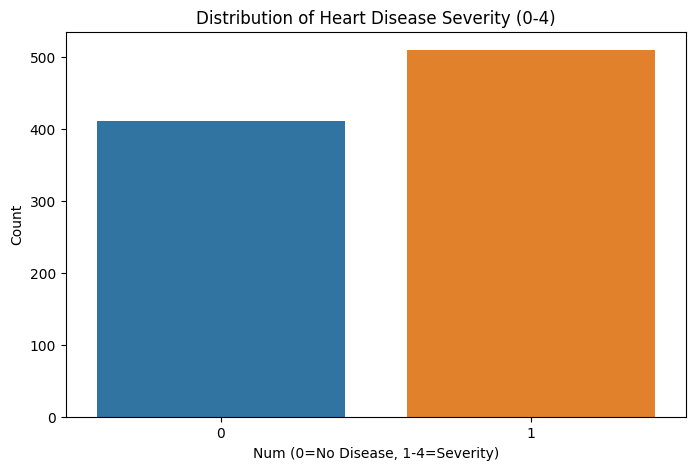

num_binary
1    55.326087
0    44.673913
Name: proportion, dtype: float64


In [208]:
# Distribution of heart disease severity
plt.figure(figsize=(8, 5))
sns.countplot(x='num_binary', data=df1, hue='num_binary', legend=False)
plt.title('Distribution of Heart Disease Severity (0-4)')
plt.xlabel('Num (0=No Disease, 1-4=Severity)')
plt.ylabel('Count')
plt.show()

# Binary distribution
print(df1['num_binary'].value_counts(normalize=True) * 100)

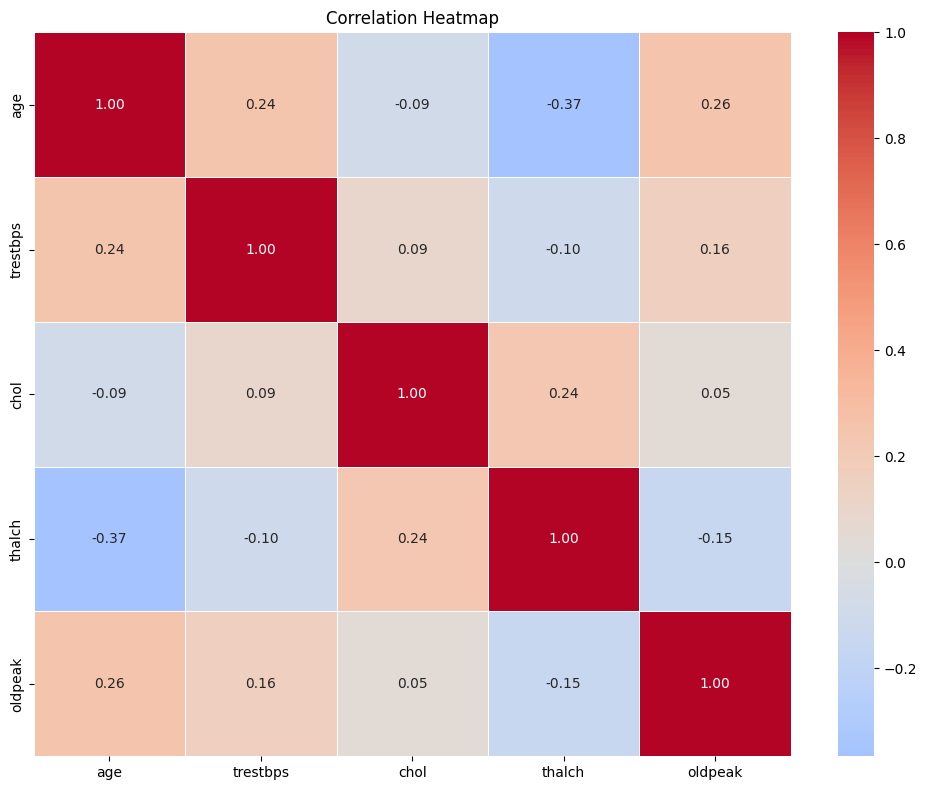

In [209]:
# Correlation heatmap for numerical features
# Select numerical features
numeric_features = X.select_dtypes(include=['int', 'float']).columns.tolist()

# Calculate correlation matrix
corr_matrix = X[numeric_features].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Machine Learning Models
### Using basic classification models: Logistic Regression, Decision Tree, and Random Forest.

In [210]:
# Train/test split 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (736, 11)
Testing: (184, 11)


In [211]:
# Handle missing values + categorical variables
# Dataset contains both:
# Numerical variables: age, trestbps, chol, thalch, oldpeak
# Categorical variables: sex, cp, fbs, restecg, exang, slope
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Identify categorical column types
categorical_features = X.select_dtypes(include=['object', 'bool', 'category']).columns

print("Numeric features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numeric features:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

Categorical features:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']


In [212]:
# Create preprocessing pipeline
# Numerical variables
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical variables
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

### Logistic Regression:

In [213]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Use Logistic Regression pipeline as lr
lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Train
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

# print("Logistic Regression")
print("--------------------")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

--------------------
Accuracy: 0.8152173913043478
ROC-AUC: 0.9043519846963176

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.73      0.78        82
           1       0.80      0.88      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.81      0.81       184
weighted avg       0.82      0.82      0.81       184


Confusion Matrix:
[[60 22]
 [12 90]]


### Decision Tree:

In [214]:
from sklearn.tree import DecisionTreeClassifier

dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=4,
        random_state=42
    ))
])

dt.fit(X_train, y_train)

y_pred_tree = dt.predict(X_test)
y_prob_tree = dt.predict_proba(X_test)[:, 1]

print("Decision Tree")
print("--------------------")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_tree))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

Decision Tree
--------------------
Accuracy: 0.8043478260869565
ROC-AUC: 0.878347680535629

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77        82
           1       0.81      0.85      0.83       102

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.80      0.80      0.80       184


Confusion Matrix:
[[61 21]
 [15 87]]


### Random Forest:

In [215]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print("--------------------")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest
--------------------
Accuracy: 0.8532608695652174
ROC-AUC: 0.9170253467240556

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.77      0.82        82
           1       0.83      0.92      0.87       102

    accuracy                           0.85       184
   macro avg       0.86      0.84      0.85       184
weighted avg       0.86      0.85      0.85       184


Confusion Matrix:
[[63 19]
 [ 8 94]]


## Compare all three models

In [216]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],

    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf)
    ],

    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_tree),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results.round(2)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.82,0.80,0.88,0.84,0.90
1,Decision Tree,0.80,0.81,0.85,0.83,0.88
2,Random Forest,0.85,0.83,0.92,0.87,0.92


#### Interpretation for the results:
- Random Forest is the strongest models across almost every metric. It detects about 92% of patients who actually have heart disease (Recall = 0.92). It has good separation between disease and non-disease cases (ROC-AUC = 0.92).
- Logistic Regression is the next competitive one. ROC-AUC of 0.90 and recall of 0.88 are quite good. Logistic Regression has the advantage of being easier to interpret clinically.
- Decision Tree is slightly weaker and is likely more sensitive to the specific train/test split.